In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [34]:
df=pd.read_csv("./dfToTrain2.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
1,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
2,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
3,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
4,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

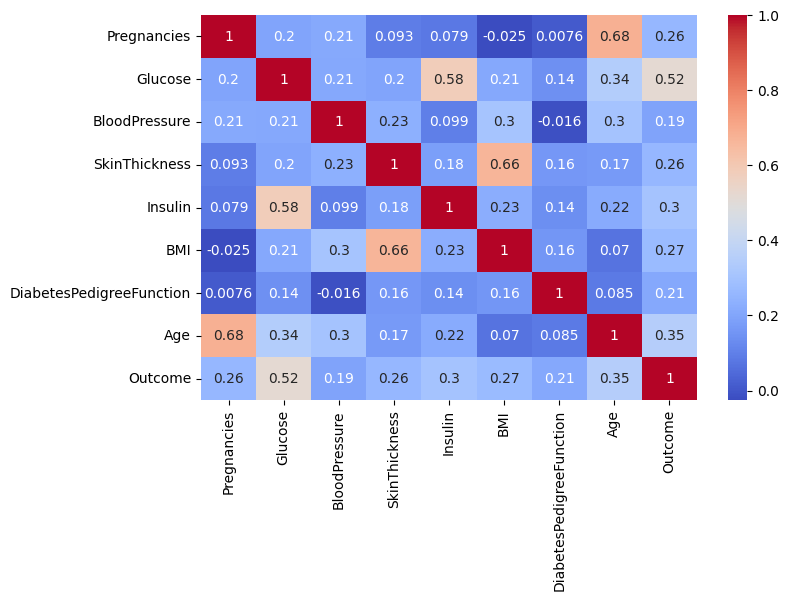

In [33]:
corr=df.corr()
corr

plt.figure(figsize=(8,5))
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.show()

In [35]:
df2=df.copy()

entrenar Modelo

In [50]:
columnas=["SkinThickness","Outcome","BloodPressure","DiabetesPedigreeFunction"]
x=df.drop(columnas,axis=1)
y=df["Outcome"]

In [67]:
columnasDrop=["SkinThickness","BloodPressure","DiabetesPedigreeFunction"]
df2=df2.drop(columnasDrop,axis=1)
df2.head()

,Pregnancies,Glucose,Insulin,BMI,Age,Outcome
0,1,89.0,94.0,28.1,21,0
1,0,137.0,168.0,43.1,33,1
2,3,78.0,88.0,31.0,26,1
3,2,197.0,543.0,30.5,53,1
4,1,189.0,846.0,30.1,59,1


In [44]:
#80% entrenamiento, 20% test
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2, random_state=42)

In [45]:
#ramdom Forest
modelo=RandomForestClassifier(n_estimators=100,random_state=42, class_weight="balanced")
modelo.fit(x_train,y_train)

#predicciones
y_pred=modelo.predict(x_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83        52
           1       0.70      0.52      0.60        27

    accuracy                           0.76        79
   macro avg       0.74      0.70      0.71        79
weighted avg       0.75      0.76      0.75        79

[[46  6]
 [13 14]]


In [ ]:
from xgboost import XGBClassifier

# Crear el modelo XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(x_train, y_train)

# Realizar predicciones
y_pred = xgb_model.predict(x_test)

# Evaluar el rendimiento del modelo
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

usar gridsearch

In [46]:
from sklearn.model_selection import GridSearchCV

parametros={
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), parametros, cv=5, n_jobs=-1, verbose=1, scoring='accuracy')
grid_search.fit(x_train, y_train)

print("Mejor parámetro:", grid_search.best_params_)
print("Mejor puntaje:", grid_search.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejor parámetro: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 300}
Mejor puntaje: 0.7927291346646185


In [59]:
modeloOptimizado=RandomForestClassifier(
    criterion="entropy",
    max_depth=5,
    min_samples_split=10,
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

modeloOptimizado.fit(x_train,y_train)
y_pred=modeloOptimizado.predict(x_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86        52
           1       0.73      0.70      0.72        27

    accuracy                           0.81        79
   macro avg       0.79      0.78      0.79        79
weighted avg       0.81      0.81      0.81        79

[[45  7]
 [ 8 19]]


smote para balancear

In [60]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=42)
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)

modeloOptimizado=RandomForestClassifier(
    criterion="gini",
    max_depth=None,
    min_samples_split=10,
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

modeloOptimizado.fit(x_train_smote,y_train_smote)
y_pred=modeloOptimizado.predict(x_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        52
           1       0.74      0.74      0.74        27

    accuracy                           0.82        79
   macro avg       0.80      0.80      0.80        79
weighted avg       0.82      0.82      0.82        79

[[45  7]
 [ 7 20]]


#GUARDAR MODELO


In [62]:
import joblib

joblib.dump(modeloOptimizado,"./modeloEntrenado/modeloEntrenado.joblib")

print("Modelo guardado")

Modelo guardado


In [68]:
df2.head()

,Pregnancies,Glucose,Insulin,BMI,Age,Outcome
0,1,89.0,94.0,28.1,21,0
1,0,137.0,168.0,43.1,33,1
2,3,78.0,88.0,31.0,26,1
3,2,197.0,543.0,30.5,53,1
4,1,189.0,846.0,30.1,59,1
